# Simulations of neutrino system $N=8$.
We generate the first order Trotterized evolution for $N=8$.

In [1]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.cost import LeastSquares  
from core_functions_Trotter import *

In [2]:
I = qt.qeye(2)

def pauli_tensors(pauli, N):
        return [qt.tensor(*(pauli if k==i else I for k in range(N))) for i in range(N)]

def generate_heisenberg_hamiltonians(N, couplings, b, theta_mix):
    sx = pauli_tensors(qt.sigmax(), N)
    sy = pauli_tensors(qt.sigmay(), N)
    sz = pauli_tensors(qt.sigmaz(), N)

    H_0 = 0
    H_int = 0
    H_XY = 0
    H_XZ = 0
    H_YZ = 0

    for i in range(N):
        H_0 += b*(np.sin(2*theta_mix)*sx[i] - np.cos(2*theta_mix)*sz[i])
        for j in range(i+1, N):
            g = couplings[f"g{i+1}_{j+1}"]

            H_int += g*(sx[i]*sx[j] + sy[i]*sy[j] + sz[i]*sz[j])
            H_XY  += 0.5*g*(sx[i]*sx[j] + sy[i]*sy[j])
            H_XZ  += 0.5*g*(sx[i]*sx[j] + sz[i]*sz[j])
            H_YZ  += 0.5*g*(sy[i]*sy[j] + sz[i]*sz[j])

    return H_0, H_int, H_XY, H_XZ, H_YZ


def generate_basis_vector(base_str):
    for c in base_str:
        if c != '0' and c != '1': raise Exception("Input string can only contain 0 and 1")
    
    vct = qt.basis(2,0) if base_str[0] == "0" else qt.basis(2,1)

    for c in base_str[1:]:
        temp = qt.basis(2,0) if c == "0" else qt.basis(2,1)
        vct = qt.tensor(vct, temp)
    
    return vct

In [3]:
N = 8
mu = 1
theta_mixing = 0.195
upsilon = 0.9
b = mu / N # free Hamiltonian 

couplings, _ = fp_couplings(N, upsilon, mu)

def pauli_tensors(pauli, N):
    return [qt.tensor(*(pauli if i==j else I for j in range(N))) for i in range(N)]

sx, sy, sz = pauli_tensors(qt.sigmax(), N), pauli_tensors(qt.sigmay(), N), pauli_tensors(qt.sigmaz(), N)

H_0, H_int, H_XY, H_XZ, H_YZ = generate_heisenberg_hamiltonians(N, couplings, b, theta_mixing)

psi00001111 = generate_basis_vector("00001111")


## Trotter error sanity check

In [4]:
dt_list = np.arange(1/mu, 41/mu) / mu
dt_list = dt_list[::2]

def compute_additive_error_Heisenberg_T1(times):
    U_heis = [(-1j*H_int*t).expm()*(-1j*H_0*t).expm() for t in times]
    U_T1 = [(-1j*(H_YZ)*t).expm()*(-1j*(H_XZ)*t).expm()*(-1j*(H_XY)*t).expm()*(-1j*H_0*t).expm() for t in times]
    add_err_values = [np.max(np.linalg.svd((U_heis[i] - U_T1[i]).full(), compute_uv=False)) for i in range(len(times))]
    return U_heis, U_T1, add_err_values

U_heis_vals, U_T1_vals, add_T1_vals = compute_additive_error_Heisenberg_T1(dt_list)

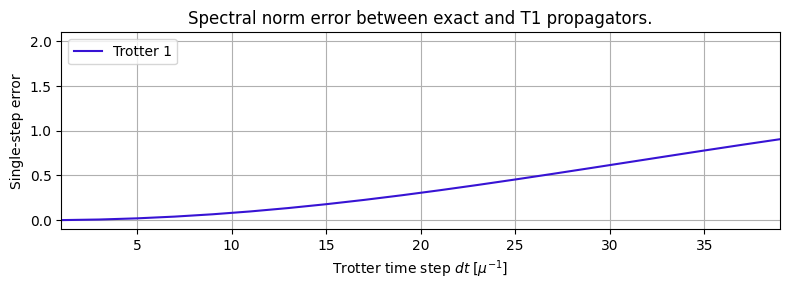

In [5]:
fig, ax=plt.subplots(figsize=(8,3))

ax.plot(dt_list, add_T1_vals, color="#3713d4", label="Trotter 1")
ax.set_title(r"Spectral norm error between exact and T1 propagators.")
ax.set_xlabel(r"Trotter time step $dt\;\left[\mu^{-1}\right]$")
ax.set_ylabel(r"Single-step error")
ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=10, va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.legend(loc=2)
ax.set_xlim(np.min(dt_list), np.max(dt_list))
ax.set_ylim(-0.1, 2.1)

plt.grid()
plt.tight_layout()
plt.show()

## Z expectation value and inversion probabilities for the finite time evolution

In [6]:
dt = 1 / mu
N_iter = 200

U_free = (-1j*H_0*dt).expm()
U_exact_dt = (-1j*H_int*dt).expm() * U_free
U_Trot1_dt = (-1j*(H_YZ)*dt).expm()*(-1j*(H_XZ)*dt).expm()*(-1j*(H_XY)*dt).expm() * U_free

psi_exact = []
psi_Trot1 = []

psi_exact.append(psi00001111)
psi_Trot1.append(psi00001111)

for i in range(1, N_iter):
    psi_exact.append(U_exact_dt*psi_exact[i-1])
    psi_Trot1.append(U_Trot1_dt*psi_Trot1[i-1])

tlist = [dt*k for k in range(0, N_iter)]

exact_Z0_expvl = [qt.expect(sz[0], state) for state in psi_exact]
Trot1_Z0_expvl = [qt.expect(sz[0], state) for state in psi_Trot1]
exact_Z1_expvl = [qt.expect(sz[1], state) for state in psi_exact]
Trot1_Z1_expvl = [qt.expect(sz[1], state) for state in psi_Trot1]
exact_Z2_expvl = [qt.expect(sz[2], state) for state in psi_exact]
Trot1_Z2_expvl = [qt.expect(sz[2], state) for state in psi_Trot1]
exact_Z3_expvl = [qt.expect(sz[3], state) for state in psi_exact]
Trot1_Z3_expvl = [qt.expect(sz[3], state) for state in psi_Trot1]
exact_Z4_expvl = [qt.expect(sz[4], state) for state in psi_exact]
Trot1_Z4_expvl = [qt.expect(sz[4], state) for state in psi_Trot1]
exact_Z5_expvl = [qt.expect(sz[5], state) for state in psi_exact]
Trot1_Z5_expvl = [qt.expect(sz[5], state) for state in psi_Trot1]
exact_Z6_expvl = [qt.expect(sz[6], state) for state in psi_exact]
Trot1_Z6_expvl = [qt.expect(sz[6], state) for state in psi_Trot1]
exact_Z7_expvl = [qt.expect(sz[7], state) for state in psi_exact]
Trot1_Z7_expvl = [qt.expect(sz[7], state) for state in psi_Trot1]

invprob_0_exact = [abs(exact_Z0_expvl[0]-exact_Z0_expvl[i])/2 for i in range(0, len(exact_Z0_expvl))]
invprob_0_Trot1 = [abs(Trot1_Z0_expvl[0]-Trot1_Z0_expvl[i])/2 for i in range(0, len(Trot1_Z0_expvl))]
invprob_1_exact = [abs(exact_Z1_expvl[0]-exact_Z1_expvl[i])/2 for i in range(0, len(exact_Z1_expvl))]
invprob_1_Trot1 = [abs(Trot1_Z1_expvl[0]-Trot1_Z1_expvl[i])/2 for i in range(0, len(Trot1_Z1_expvl))]
invprob_2_exact = [abs(exact_Z2_expvl[0]-exact_Z2_expvl[i])/2 for i in range(0, len(exact_Z2_expvl))]
invprob_2_Trot1 = [abs(Trot1_Z2_expvl[0]-Trot1_Z2_expvl[i])/2 for i in range(0, len(Trot1_Z2_expvl))]
invprob_3_exact = [abs(exact_Z3_expvl[0]-exact_Z3_expvl[i])/2 for i in range(0, len(exact_Z3_expvl))]
invprob_3_Trot1 = [abs(Trot1_Z3_expvl[0]-Trot1_Z3_expvl[i])/2 for i in range(0, len(Trot1_Z3_expvl))]
invprob_4_exact = [abs(exact_Z4_expvl[0]-exact_Z4_expvl[i])/2 for i in range(0, len(exact_Z4_expvl))]
invprob_4_Trot1 = [abs(Trot1_Z4_expvl[0]-Trot1_Z4_expvl[i])/2 for i in range(0, len(Trot1_Z4_expvl))]
invprob_5_exact = [abs(exact_Z5_expvl[0]-exact_Z5_expvl[i])/2 for i in range(0, len(exact_Z5_expvl))]
invprob_5_Trot1 = [abs(Trot1_Z5_expvl[0]-Trot1_Z5_expvl[i])/2 for i in range(0, len(Trot1_Z5_expvl))]
invprob_6_exact = [abs(exact_Z6_expvl[0]-exact_Z6_expvl[i])/2 for i in range(0, len(exact_Z6_expvl))]
invprob_6_Trot1 = [abs(Trot1_Z6_expvl[0]-Trot1_Z6_expvl[i])/2 for i in range(0, len(Trot1_Z6_expvl))]
invprob_7_exact = [abs(exact_Z7_expvl[0]-exact_Z7_expvl[i])/2 for i in range(0, len(exact_Z7_expvl))]
invprob_7_Trot1 = [abs(Trot1_Z7_expvl[0]-Trot1_Z7_expvl[i])/2 for i in range(0, len(Trot1_Z7_expvl))]

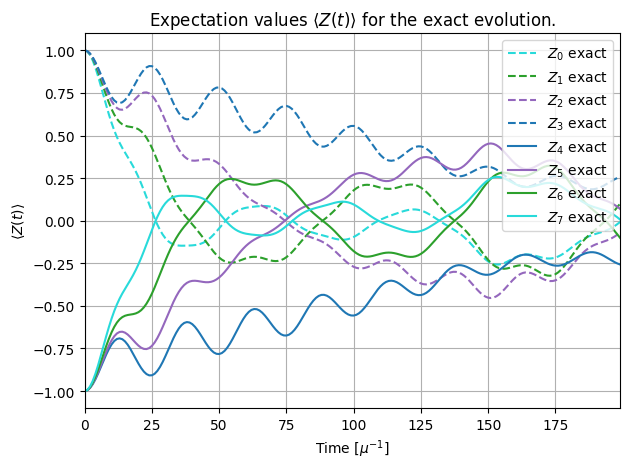

In [8]:
# ----------------
# --- Plotting --- 
# ----------------

show_Trotter = False

# ----- Plot Z expectation value -----

fig, ax=plt.subplots()

ax.plot(tlist, exact_Z0_expvl, color="#28dada", linestyle="--", label=r"$Z_0$ exact")
ax.plot(tlist, exact_Z1_expvl, color="#2ca02c", linestyle="--", label=r"$Z_1$ exact")
ax.plot(tlist, exact_Z2_expvl, color="#9467bd", linestyle="--", label=r"$Z_2$ exact")
ax.plot(tlist, exact_Z3_expvl, color="#1f77b4", linestyle="--", label=r"$Z_3$ exact")
ax.plot(tlist, exact_Z4_expvl, color="#1f77b4", label=r"$Z_4$ exact")
ax.plot(tlist, exact_Z5_expvl, color="#9467bd", label=r"$Z_5$ exact")
ax.plot(tlist, exact_Z6_expvl, color="#2ca02c", label=r"$Z_6$ exact")
ax.plot(tlist, exact_Z7_expvl, color="#28dada", label=r"$Z_7$ exact")

if show_Trotter:
    ax.plot(tlist, Trot1_Z0_expvl, color="#9ecae1", linestyle="--", label=r"$Z_0$ Trot1")
    ax.plot(tlist, Trot1_Z1_expvl, color="#fdae6b", linestyle="--", label=r"$Z_1$ Trot1")
    ax.plot(tlist, Trot1_Z2_expvl, color="#a1d99b", linestyle="--", label=r"$Z_2$ Trot1")
    ax.plot(tlist, Trot1_Z3_expvl, color="#fb6a4a", linestyle="--", label=r"$Z_3$ Trot1")
    ax.plot(tlist, Trot1_Z4_expvl, color="#f16913", linestyle="--", label=r"$Z_4$ Trot1")
    ax.plot(tlist, Trot1_Z5_expvl, color="#74c476", linestyle="--", label=r"$Z_5$ Trot1")
    ax.plot(tlist, Trot1_Z6_expvl, color="#ffb84d", linestyle="--", label=r"$Z_6$ Trot1")
    ax.plot(tlist, Trot1_Z7_expvl, color="#bdd7e7", linestyle="--", label=r"$Z_7$ Trot1")


ax.set_title(r"Expectation values $\langle Z(t)\rangle$ for the exact evolution.")
ax.set_xlabel(r"Time $[\mu^{-1}]$")
ax.set_ylabel(r"$\langle Z(t)\rangle$")
ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=10, va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.legend(loc=1)
ax.set_xlim(np.min(tlist), np.max(tlist))
ax.set_ylim(-1.1, 1.1)

plt.grid()
plt.tight_layout()
plt.show()

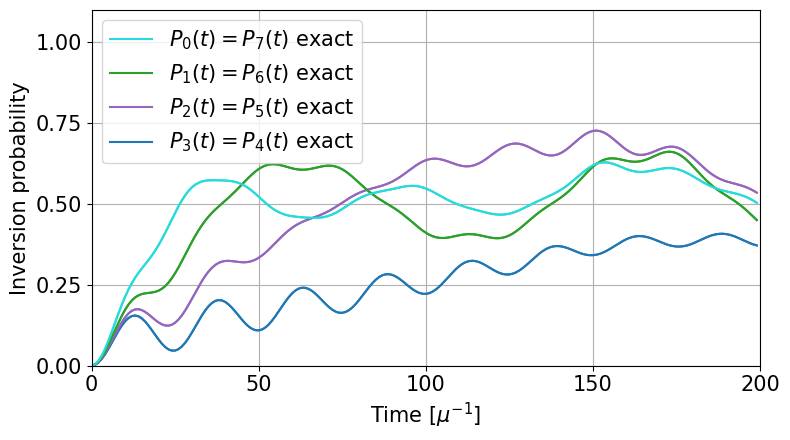

In [13]:
# ----- Plot inversion probabilities -----

fig, ax=plt.subplots(figsize=(16/2,9/2))

step_plot = int(3 * N_iter / 100)

ax.plot(tlist, invprob_0_exact, color="#28dada", label=r"$P_0(t)=P_7(t)$ exact")
ax.plot(tlist, invprob_1_exact, color="#2ca02c", label=r"$P_1(t)=P_6(t)$ exact")
ax.plot(tlist, invprob_2_exact, color="#9467bd", label=r"$P_2(t)=P_5(t)$ exact")
ax.plot(tlist, invprob_3_exact, color="#1f77b4", label=r"$P_3(t)=P_4(t)$ exact")
ax.plot(tlist, invprob_4_exact, color="#1f77b4")
ax.plot(tlist, invprob_5_exact, color="#9467bd")
ax.plot(tlist, invprob_6_exact, color="#2ca02c")
ax.plot(tlist, invprob_7_exact, color="#28dada")

if show_Trotter:
    ax.plot(tlist, invprob_0_Trot1, color="#aec7e8", linestyle="--", label=r"$P_0(t)$ Trot1")
    ax.plot(tlist, invprob_1_Trot1, color="#98df8a", linestyle="--", label=r"$P_1(t)$ Trot1")
    ax.plot(tlist, invprob_2_Trot1, color="#c5b0d5", linestyle="--", label=r"$P_2(t)$ Trot1")
    ax.plot(tlist, invprob_3_Trot1, color="#ffbb78", linestyle="--", label=r"$P_3(t)$ Trot1")
    ax.plot(tlist, invprob_4_Trot1, color="#aec7e8", linestyle="--", label=r"$P_4(t)$ Trot1")
    ax.plot(tlist, invprob_5_Trot1, color="#98df8a", linestyle="--", label=r"$P_5(t)$ Trot1")
    ax.plot(tlist, invprob_6_Trot1, color="#c5b0d5", linestyle="--", label=r"$P_6(t)$ Trot1")
    ax.plot(tlist, invprob_7_Trot1, color="#ffbb78", linestyle="--", label=r"$P_7(t)$ Trot1")

#ax.set_title(r"Inversion probabilities $P(t)=|\langle Z(0)\rangle-\langle Z(t)\rangle|/2$ for the exact evolution.")
ax.set_xlabel(r"Time $[\mu^{-1}]$", fontsize=15)
ax.set_ylabel(r"Inversion probability", fontsize=15)
ax.legend(fontsize=15)
ax.set_xlim(np.min(tlist), np.max(tlist))
ax.set_ylim(0, 1.1)
ax.set_xticks([0,50,100,150,200])
ax.set_yticks([0,0.25,0.50,0.75,1])
ax.tick_params("both", labelsize=15)

plt.grid()
plt.tight_layout()
plt.show()

## Inversion probabilities as a function of the Trotter time step $dt$ (fig. 5 Trapped Ions paper)

In [74]:
dt_list = np.arange(1,41) / mu

expect_Z0_0 = qt.expect(sz[0], psi00001111)
expect_Z1_0 = qt.expect(sz[1], psi00001111)
expect_Z2_0 = qt.expect(sz[2], psi00001111)
expect_Z3_0 = qt.expect(sz[3], psi00001111)
expect_Z4_0 = qt.expect(sz[4], psi00001111)
expect_Z5_0 = qt.expect(sz[5], psi00001111)
expect_Z6_0 = qt.expect(sz[6], psi00001111)
expect_Z7_0 = qt.expect(sz[7], psi00001111)

invprob_dt_exact_0 = []
invprob_dt_Trot1_0 = []
invprob_dt_exact_1 = []
invprob_dt_Trot1_1 = []
invprob_dt_exact_2 = []
invprob_dt_Trot1_2 = []
invprob_dt_exact_3 = []
invprob_dt_Trot1_3 = []
invprob_dt_exact_4 = []
invprob_dt_Trot1_4 = []
invprob_dt_exact_5 = []
invprob_dt_Trot1_5 = []
invprob_dt_exact_6 = []
invprob_dt_Trot1_6 = []
invprob_dt_exact_7 = []
invprob_dt_Trot1_7 = []


for dt in dt_list:
    U_free = (-1j*H_0*dt).expm()
    U_exact_dt = (-1j*H_int*dt).expm() * U_free
    U_Trot1_dt = (-1j*(H_YZ)*dt).expm()*(-1j*(H_XZ)*dt).expm()*(-1j*(H_XY)*dt).expm() * U_free

    psi_exact_evol = U_exact_dt*psi00001111
    psi_Trot1_evol = U_Trot1_dt*psi00001111

    invprob_dt_exact_0.append(abs(expect_Z0_0-qt.expect(sz[0], psi_exact_evol))/2)
    invprob_dt_Trot1_0.append(abs(expect_Z0_0-qt.expect(sz[0], psi_Trot1_evol))/2)
    invprob_dt_exact_1.append(abs(expect_Z1_0-qt.expect(sz[1], psi_exact_evol))/2)
    invprob_dt_Trot1_1.append(abs(expect_Z1_0-qt.expect(sz[1], psi_Trot1_evol))/2)
    invprob_dt_exact_2.append(abs(expect_Z2_0-qt.expect(sz[2], psi_exact_evol))/2)
    invprob_dt_Trot1_2.append(abs(expect_Z2_0-qt.expect(sz[2], psi_Trot1_evol))/2)
    invprob_dt_exact_3.append(abs(expect_Z3_0-qt.expect(sz[3], psi_exact_evol))/2)
    invprob_dt_Trot1_3.append(abs(expect_Z3_0-qt.expect(sz[3], psi_Trot1_evol))/2)
    invprob_dt_exact_4.append(abs(expect_Z4_0-qt.expect(sz[4], psi_exact_evol))/2)
    invprob_dt_Trot1_4.append(abs(expect_Z4_0-qt.expect(sz[4], psi_Trot1_evol))/2)
    invprob_dt_exact_5.append(abs(expect_Z5_0-qt.expect(sz[5], psi_exact_evol))/2)
    invprob_dt_Trot1_5.append(abs(expect_Z5_0-qt.expect(sz[5], psi_Trot1_evol))/2)
    invprob_dt_exact_6.append(abs(expect_Z6_0-qt.expect(sz[6], psi_exact_evol))/2)
    invprob_dt_Trot1_6.append(abs(expect_Z6_0-qt.expect(sz[6], psi_Trot1_evol))/2)
    invprob_dt_exact_7.append(abs(expect_Z7_0-qt.expect(sz[7], psi_exact_evol))/2)
    invprob_dt_Trot1_7.append(abs(expect_Z7_0-qt.expect(sz[7], psi_Trot1_evol))/2)

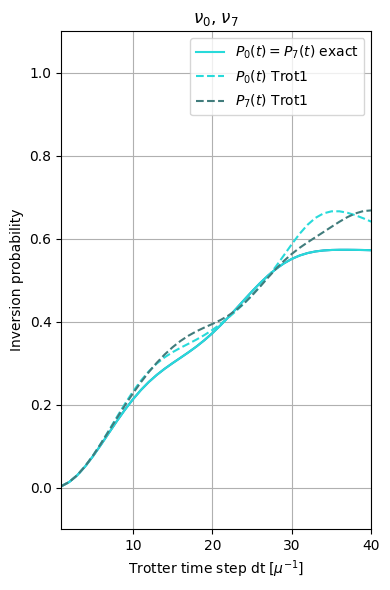

In [75]:
# ----------------
# --- Plotting --- 
# ----------------

show_Trotter = True

# ----- Plot inversion probabilities nu0, nu7 -----

fig, ax=plt.subplots(figsize=(4,6))

ax.plot(dt_list, invprob_dt_exact_0, color="#1f77b4")
ax.plot(dt_list, invprob_dt_exact_7, color="#28dada", label=r"$P_0(t)=P_7(t)$ exact")

if show_Trotter:
    ax.plot(dt_list, invprob_dt_Trot1_0, color="#28dada", linestyle="--", label=r"$P_0(t)$ Trot1")
    ax.plot(dt_list, invprob_dt_Trot1_7, color="#417c7c", linestyle="--", label=r"$P_7(t)$ Trot1")

ax.set_title(r"$\nu_0$, $\nu_7$")
ax.set_xlabel(r"Trotter time step $\text{dt}\; \left[\mu^{-1}\right]$")
ax.set_ylabel(r"Inversion probability")
ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=10, va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.legend()
ax.set_xlim(np.min(dt_list), np.max(dt_list))
ax.set_ylim(-0.1, 1.1)

plt.grid()
plt.tight_layout()
plt.show()

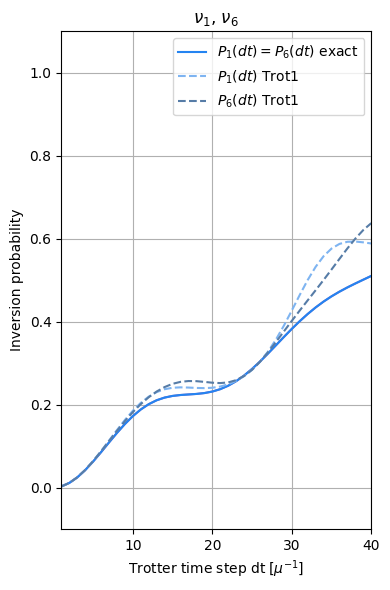

In [76]:
# ----- Plot inversion probabilities nu1, nu6 -----

fig, ax=plt.subplots(figsize=(4,6))

ax.plot(dt_list, invprob_dt_exact_1, color="#9467bd")
ax.plot(dt_list, invprob_dt_exact_6, color="#2484f1", label=r"$P_1(dt)=P_6(dt)$ exact")

if show_Trotter:
    ax.plot(dt_list, invprob_dt_Trot1_1, color="#7eb4f1", linestyle="--", label=r"$P_1(dt)$ Trot1")
    ax.plot(dt_list, invprob_dt_Trot1_6, color="#567ca7", linestyle="--", label=r"$P_6(dt)$ Trot1")

ax.set_title(r"$\nu_1$, $\nu_6$")
ax.set_xlabel(r"Trotter time step $\text{dt}\; \left[\mu^{-1}\right]$")
ax.set_ylabel(r"Inversion probability")
ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=10, va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.legend()
ax.set_xlim(np.min(dt_list), np.max(dt_list))
ax.set_ylim(-0.1, 1.1)

plt.grid()
plt.tight_layout()
plt.show()

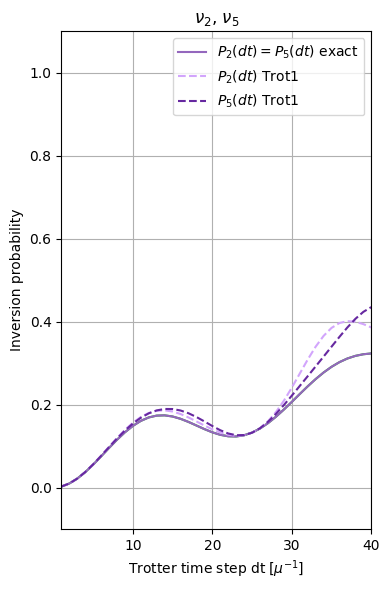

In [77]:
# ----- Plot inversion probabilities nu2, nu5 -----

fig, ax=plt.subplots(figsize=(4,6))

ax.plot(dt_list, invprob_dt_exact_2, color="#2ca02c")
ax.plot(dt_list, invprob_dt_exact_5, color="#9467bd", label=r"$P_2(dt)=P_5(dt)$ exact")

if show_Trotter:
    ax.plot(dt_list, invprob_dt_Trot1_2, color="#d2a5fc", linestyle="--", label=r"$P_2(dt)$ Trot1")
    ax.plot(dt_list, invprob_dt_Trot1_5, color="#6628a0", linestyle="--", label=r"$P_5(dt)$ Trot1")

ax.set_title(r"$\nu_2$, $\nu_5$")
ax.set_xlabel(r"Trotter time step $\text{dt}\; \left[\mu^{-1}\right]$")
ax.set_ylabel(r"Inversion probability")
ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=10, va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.legend()
ax.set_xlim(np.min(dt_list), np.max(dt_list))
ax.set_ylim(-0.1, 1.1)

plt.grid()
plt.tight_layout()
plt.show()

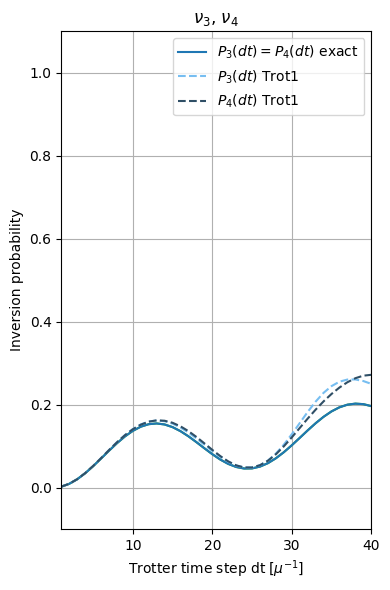

In [78]:
# ----- Plot inversion probabilities nu3, nu4 -----

fig, ax=plt.subplots(figsize=(4,6))

ax.plot(dt_list, invprob_dt_exact_3, color="#2ca02c")
ax.plot(dt_list, invprob_dt_exact_4, color="#1f77b4", label=r"$P_3(dt)=P_4(dt)$ exact")

if show_Trotter:
    ax.plot(dt_list, invprob_dt_Trot1_3, color="#77bef1", linestyle="--", label=r"$P_3(dt)$ Trot1")
    ax.plot(dt_list, invprob_dt_Trot1_4, color="#2f4f66", linestyle="--", label=r"$P_4(dt)$ Trot1")

ax.set_title(r"$\nu_3$, $\nu_4$")
ax.set_xlabel(r"Trotter time step $\text{dt}\; \left[\mu^{-1}\right]$")
ax.set_ylabel(r"Inversion probability")
ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=10, va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.legend()
ax.set_xlim(np.min(dt_list), np.max(dt_list))
ax.set_ylim(-0.1, 1.1)

plt.grid()
plt.tight_layout()
plt.show()

## Time evolution of the inversion probability for neutrino $\nu_1$ using a time step $dt = 16\mu^{-1}$ (fig. 6)

In [72]:
T_total = 3000

dt_exact = 1 / mu
dt = 8 / mu

r_exact = int(T_total / dt_exact)
r_Trot1 = int(T_total / dt)

U_free_dt_exact = (-1j*H_0*dt_exact).expm()
U_exact_dt_exact = (-1j*H_int*dt_exact).expm() * U_free_dt_exact

U_free_dt = (-1j*H_0*dt).expm()
U_Trot1_dt = (-1j*(H_YZ)*dt).expm()*(-1j*(H_XZ)*dt).expm()*(-1j*(H_XY)*dt).expm() * U_free_dt

psi_exact = []
psi_Trot1 = []

psi_exact.append(psi00001111)
psi_Trot1.append(psi00001111)

for i in range(1, r_exact): psi_exact.append(U_exact_dt_exact*psi_exact[i-1])
for i in range(1, r_Trot1): psi_Trot1.append(U_Trot1_dt*psi_Trot1[i-1])

tlist_exact = [dt_exact*k for k in range(0, r_exact)]
tlist_Trot1 = [dt*k for k in range(0, r_Trot1)]

# exact_Z1_expvl = [qt.expect(sz[1], state) for state in psi_exact]
# Trot1_Z1_expvl = [qt.expect(sz[1], state) for state in psi_Trot1]

exact_Z3_expvl = [qt.expect(sz[3], state) for state in psi_exact]
Trot1_Z3_expvl = [qt.expect(sz[3], state) for state in psi_Trot1]

# invprob_1_exact = [abs(exact_Z1_expvl[0]-exact_Z1_expvl[i])/2 for i in range(0, len(exact_Z1_expvl))]
# invprob_1_Trot1 = [abs(Trot1_Z1_expvl[0]-Trot1_Z1_expvl[i])/2 for i in range(0, len(Trot1_Z1_expvl))]

invprob_3_exact = [abs(exact_Z3_expvl[0]-exact_Z3_expvl[i])/2 for i in range(0, len(exact_Z3_expvl))]
invprob_3_Trot1 = [abs(Trot1_Z3_expvl[0]-Trot1_Z3_expvl[i])/2 for i in range(0, len(Trot1_Z3_expvl))]


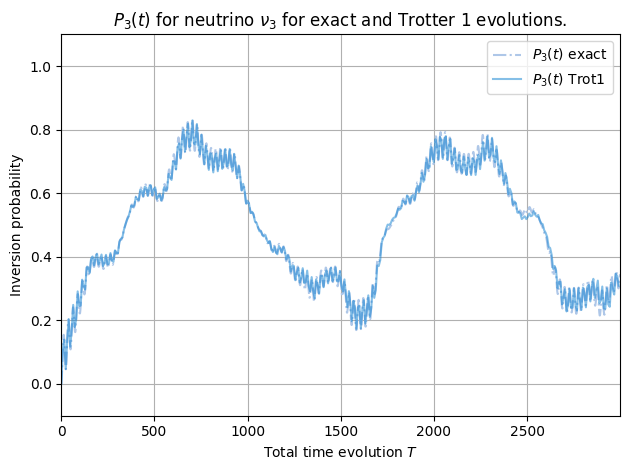

In [73]:

# ----- Plot inversion probabilities -----

fig, ax=plt.subplots()

# ax.plot(tlist_exact, invprob_1_exact, color="#aec7e8", label=r"$P_1(t)$ exact")
# ax.plot(tlist_Trot1, invprob_1_Trot1, color="#1f77b4", linestyle="--", label=r"$P_1(t)$ Trot1")

ax.plot(tlist_exact, invprob_3_exact, color="#aec7e8", linestyle="-.", label=r"$P_3(t)$ exact")
ax.plot(tlist_Trot1, invprob_3_Trot1, color="#0d80d1", alpha=0.5, label=r"$P_3(t)$ Trot1")

ax.set_title(r"$P_3(t)$ for neutrino $\nu_3$ for exact and Trotter 1 evolutions.")
ax.set_xlabel(r"Total time evolution $T$")
ax.set_ylabel(r"Inversion probability")
ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=10, va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.legend()
ax.set_xlim(np.min(tlist_exact), np.max(tlist_exact))
ax.set_ylim(-0.1, 1.1)

plt.grid()
plt.tight_layout()
plt.show()